In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(42)
random.seed(42)

In [2]:
# The 6 hiring funnel stages every applicant moves through
FUNNEL_STAGES = [
    "Applied",
    "Screened",
    "Phone Interview",
    "Technical Interview",
    "Final Interview",
    "Offer Extended"
]

# Drop-off rate at each stage (what % make it to the NEXT stage)
# These are realistic HR benchmarks
STAGE_PASS_RATES = {
    "Applied":             0.45,   # 45% get screened
    "Screened":            0.60,   # 60% get a phone interview
    "Phone Interview":     0.55,   # 55% advance to technical
    "Technical Interview": 0.50,   # 50% reach final round
    "Final Interview":     0.70,   # 70% get an offer
    "Offer Extended":      0.80,   # 80% accept the offer
}

DEPARTMENTS = ["Engineering", "Sales", "HR", "Finance", "Marketing", "Operations"]
ROLE_LEVELS  = ["Junior", "Mid", "Senior", "Lead"]
RECRUITERS   = [f"REC{str(i).zfill(3)}" for i in range(1, 16)]  # 15 recruiters

In [3]:
records = []

for applicant_id in range(1, 5001):
    department   = random.choice(DEPARTMENTS)
    role_level   = random.choice(ROLE_LEVELS)
    recruiter_id = random.choice(RECRUITERS)

    # Random application start date in the past 2 years
    start_date = datetime(2023, 1, 1) + timedelta(days=random.randint(0, 730))

    # Walk the applicant through each funnel stage
    current_date  = start_date
    last_stage    = "Applied"
    stages_passed = 1

    for stage in FUNNEL_STAGES:
        pass_rate = STAGE_PASS_RATES[stage]
        advanced  = random.random() < pass_rate

        # Days spent in this stage (role level affects speed)
        base_days = {"Junior": 4, "Mid": 6, "Senior": 9, "Lead": 12}[role_level]
        days_in_stage = max(1, int(np.random.normal(loc=base_days, scale=2)))
        current_date += timedelta(days=days_in_stage)

        if not advanced:
            last_stage = stage
            break
        else:
            last_stage = stage
            stages_passed += 1

    # Time-to-hire = total calendar days from application to last stage
    time_to_hire = (current_date - start_date).days

    # Offer accepted only if the applicant reached "Offer Extended"
    offer_accepted = 1 if (last_stage == "Offer Extended" and random.random() < 0.80) else 0

    records.append({
        "applicant_id":    applicant_id,
        "department":      department,
        "role_level":      role_level,
        "recruiter_id":    recruiter_id,
        "application_date": start_date.strftime("%Y-%m-%d"),
        "last_stage":      last_stage,
        "stages_passed":   stages_passed,
        "time_to_hire":    time_to_hire,
        "offer_accepted":  offer_accepted,
    })

df = pd.DataFrame(records)
print(df.shape)
print(df.head())

(5000, 9)
   applicant_id  department role_level recruiter_id application_date  \
0             1  Operations     Junior       REC001       2023-10-09   
1             2   Marketing     Junior       REC010       2024-03-08   
2             3   Marketing        Mid       REC012       2024-10-27   
3             4     Finance        Mid       REC008       2024-08-26   
4             5       Sales       Lead       REC006       2023-10-12   

            last_stage  stages_passed  time_to_hire  offer_accepted  
0  Technical Interview              4            19               0  
1  Technical Interview              4            18               0  
2              Applied              1             5               0  
3             Screened              2            12               0  
4             Screened              2            23               0  


In [4]:
# Quick sanity check — see how many applicants reached each stage
print(df["last_stage"].value_counts())

# Save to CSV
df.to_csv("hiring_funnel_data.csv", index=False)
print("Saved: hiring_funnel_data.csv")

last_stage
Applied                2727
Screened                903
Phone Interview         636
Technical Interview     373
Offer Extended          262
Final Interview          99
Name: count, dtype: int64
Saved: hiring_funnel_data.csv


In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("hiring_funnel_data.csv")

# Encode categorical columns into numbers
le = LabelEncoder()

df["department_encoded"]  = le.fit_transform(df["department"])
df["role_level_encoded"]  = le.fit_transform(df["role_level"])
df["recruiter_encoded"]   = le.fit_transform(df["recruiter_id"])
df["last_stage_encoded"]  = le.fit_transform(df["last_stage"])

print("Columns ready:")
print(df[["department_encoded","role_level_encoded",
          "recruiter_encoded","last_stage_encoded",
          "stages_passed","offer_accepted","time_to_hire"]].head())

Columns ready:
   department_encoded  role_level_encoded  recruiter_encoded  \
0                   4                   0                  0   
1                   3                   0                  9   
2                   3                   2                 11   
3                   1                   2                  7   
4                   5                   1                  5   

   last_stage_encoded  stages_passed  offer_accepted  time_to_hire  
0                   5              4               0            19  
1                   5              4               0            18  
2                   0              1               0             5  
3                   4              2               0            12  
4                   4              2               0            23  


In [7]:
# Features (X) = what we use to predict
# Target  (y) = what we're predicting
features = [
    "department_encoded",
    "role_level_encoded",
    "recruiter_encoded",
    "last_stage_encoded",
    "stages_passed",
    "offer_accepted"
]

X = df[features]
y = df["time_to_hire"]

# Split: 80% training data, 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

print("=== Model Performance ===")
print(f"R² Score  : {r2_score(y_test, y_pred):.4f}")
print(f"MAE (days): {mean_absolute_error(y_test, y_pred):.2f}")

=== Model Performance ===
R² Score  : 0.6397
MAE (days): 5.55


In [8]:
# Which features drive time-to-hire the most?
coef_df = pd.DataFrame({
    "Feature":     features,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

print("=== Feature Coefficients ===")
print(coef_df.to_string(index=False))

=== Feature Coefficients ===
           Feature  Coefficient
     stages_passed     6.655053
role_level_encoded     1.798742
last_stage_encoded     0.107000
department_encoded     0.022768
 recruiter_encoded     0.000373
    offer_accepted    -2.868521


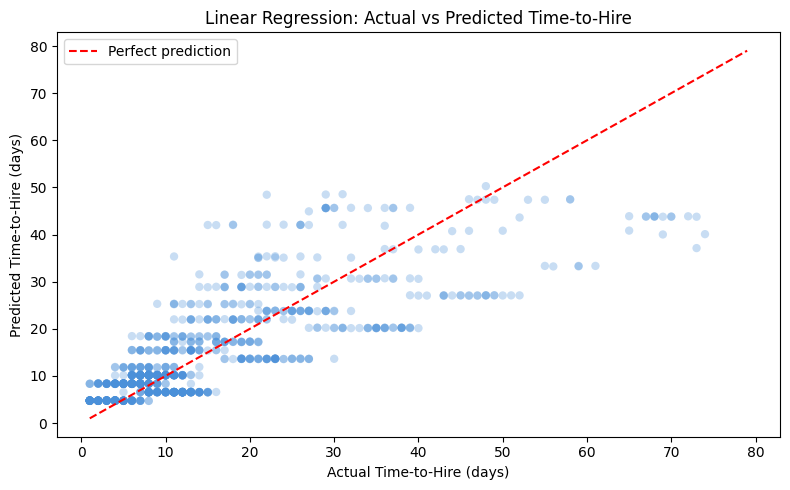

Chart saved.


In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color="#4A90D9", edgecolors="none")
plt.plot([y.min(), y.max()], [y.min(), y.max()],
         color="red", linewidth=1.5, linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Time-to-Hire (days)")
plt.ylabel("Predicted Time-to-Hire (days)")
plt.title("Linear Regression: Actual vs Predicted Time-to-Hire")
plt.legend()
plt.tight_layout()
plt.savefig("regression_actual_vs_predicted.png", dpi=150)
plt.show()
print("Chart saved.")

In [10]:
coef_df.to_csv("regression_coefficients.csv", index=False)

results_df = X_test.copy()
results_df["actual_time_to_hire"]    = y_test.values
results_df["predicted_time_to_hire"] = y_pred.round(1)
results_df.to_csv("regression_predictions.csv", index=False)

print("Saved: regression_coefficients.csv")
print("Saved: regression_predictions.csv")

Saved: regression_coefficients.csv
Saved: regression_predictions.csv
